## Portfolio Update 2: Tidy Data Project – 2008 Olympic Medalists

FIRST, in the Command Prompt add "cd PortfolioUpdate2".

SECOND, read every markdown for a description of the preceeding/proceeding code block. Press the "Run" button to run the code for each block. 

## Load and Inspect the Dataset

First We will load the dataset and look at its structure.  
Understanding the columns and missing values helps determine how the dataset must be reshaped to make it tidy.

In [116]:
# Import Everything Necessary

import sys
print(sys.executable)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load the Olympic medalists dataset
df_olympics = pd.read_csv("olympics_08_medalists.csv")

print("The column names are:")
print(df_olympics.columns)

print("The first 5 rows of the dataset are:")
display(df_olympics.head())

print("Missing values in each column:")
print(df_olympics.isnull().sum())

print("Summary statistics for the dataset:")
display(df_olympics.describe(include='all'))

c:\Users\21rwo\OneDrive\Documents\GitHub\Oesterle-Data-Science-Portfolio\venv\Scripts\python.exe
The column names are:
Index(['medalist_name', 'male_archery', 'female_archery', 'male_athletics',
       'female_athletics', 'male_badminton', 'female_badminton',
       'male_baseball', 'male_basketball', 'female_basketball', 'male_boxing',
       'male_canoeing and kayaking', 'female_canoeing and kayaking',
       'male_road bicycle racing', 'female_road bicycle racing',
       'male_track cycling', 'female_track cycling', 'male_mountain biking',
       'female_mountain biking', 'male_bmx', 'female_bmx', 'male_diving',
       'female_diving', 'female_equestrian sport', 'male_equestrian sport',
       'male_fencing', 'female_fencing', 'male_field hockey',
       'female_field hockey', 'male_association football',
       'female_association football', 'male_artistic gymnastics',
       'female_artistic gymnastics', 'female_rhythmic gymnastics',
       'male_trampoline gymnastics', 'female_t

,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
0,Aaron Armstrong,NaN,NaN,gold,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Peirsol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abdullo Tangriev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abeer Abdelrahman,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,bronze,NaN,NaN,NaN
4,Abhinav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values in each column:
medalist_name                    0
male_archery                  1864
female_archery                1866
male_athletics                1790
female_athletics              1794
                              ... 
male_weightlifting            1851
female_weightlifting          1854
male_freestyle wrestling      1847
female_freestyle wrestling    1859
male_greco-roman wrestling    1848
Length: 71, dtype: int64
Summary statistics for the dataset:


,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
count,1875,11,9,85,81,12,10,72,35,36,...,6,36,36,39,39,24,21,28,16,27
unique,1875,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
top,Aaron Armstrong,bronze,bronze,silver,silver,silver,silver,silver,bronze,bronze,...,gold,bronze,gold,silver,gold,gold,bronze,bronze,bronze,bronze
freq,1,4,4,31,28,4,4,24,12,12,...,2,12,12,13,13,8,7,14,8,13


As you can see, even in just the first 5 rows of the Dataset, the original organization of the data has way too many columns and way too many null values. This is not tidy and therefore not useful. 

## Use pd.melt()

The original dataset has it so that the Gender-Sport are the Columns.

This means multiple variables are stored in column names, which violates tidy data principles.

"pd.melt()" converts the dataset so that the individual athlete's name is the row and their medal, gender, and sport is the column.

In [117]:
# Melt the Dataset
df_olympics_melted = pd.melt(
    df_olympics,
    id_vars=['medalist_name'],  
    var_name='gender_sport',     
    value_name='medal'
)


# Preview the Melted dataset
display(df_olympics_melted.head())

,medalist_name,gender_sport,medal
0,Aaron Armstrong,male_archery,NaN
1,Aaron Peirsol,male_archery,NaN
2,Abdullo Tangriev,male_archery,NaN
3,Abeer Abdelrahman,male_archery,NaN
4,Abhinav,male_archery,NaN


## Now we will clean it up by Splitting the Dataset and Dropping Null Values.

Splitting the dataset will turn the "Gender-Sport" variable into "Gender" and "Sport" variables.
Dropping the Null Values will eliminate all "NaN"s from appearing.

In [118]:
# Drop null values
df_olympics_melted = df_olympics_melted.dropna(subset=['medal'])

# Split the Dataset
df_olympics_melted[['gender','sport']] = df_olympics_melted['gender_sport'].str.split("_", expand=True)

# Drop the original combined column
df_olympics_tidy = df_olympics_melted.drop(columns=['gender_sport'])

# Preview the tidy dataset
display(df_olympics_tidy.head())

,medalist_name,medal,gender,sport
177,Bair Badënov,bronze,male,archery
676,Ilario Di Buò,silver,male,archery
682,Im Dong-hyun,gold,male,archery
760,Jiang Lin,bronze,male,archery
920,Lee Chang-hwan,gold,male,archery


## Cleaning the Dataset

After splitting the variables, we can clean it up using "str.replace()"

In [119]:
df_olympics_tidy['medalist_name'] = df_olympics_tidy['medalist_name'].str.replace("†", "").str.strip()
df_olympics_tidy['medal'] = df_olympics_tidy['medal'].str.replace(" ", "").str.capitalize()
df_olympics_tidy['gender'] = df_olympics_tidy['gender'].str.replace(" ", "").str.capitalize()
df_olympics_tidy['sport'] = df_olympics_tidy['sport'].str.replace(" ", "").str.capitalize()
df_olympics_tidy['sport'] = df_olympics_tidy['sport'].str.replace("-", " ").str.strip()

# Preview the cleaned dataset
display(df_olympics_tidy.head())

,medalist_name,medal,gender,sport
177,Bair Badënov,Bronze,Male,Archery
676,Ilario Di Buò,Silver,Male,Archery
682,Im Dong-hyun,Gold,Male,Archery
760,Jiang Lin,Bronze,Male,Archery
920,Lee Chang-hwan,Gold,Male,Archery


## Tidy Data Explanation

Now the dataset follows tidy data principles:
- Each variable is in its own column (medalist_name, medal, gender, sport)
- Each observation is in its own row (one athlete winning one medal)
- Each type of observational unit is stored in one table (Olympic medal results)

This makes the dataset easier to analyze, group, and visualize.

## Pivot Table Analysis

Pivot tables summarize data by applying aggregation functions.

Using "pd.pivot_table()", I will calculate the total number of medals for each sport.

In [120]:
# Pivot: count number of medals by sport and medal type
pivot_medals_sport = pd.pivot_table(
    df_olympics_tidy,
    values='medalist_name',  # each row represents a medal; count athletes
    index='sport',           # group by sport
    columns='medal',         # count medals by type: Bronze, Silver, Gold
    aggfunc='count',         # count occurrences
    fill_value=0             # replace missing combinations with 0
)

# Reorder columns: Bronze, Silver, Gold
pivot_medals_sport = pivot_medals_sport[['Bronze', 'Silver', 'Gold']]

# Remove the index name so "sport" doesn't appear above the index
pivot_medals_sport.index.name = None

# Preview the pivot table
display(pivot_medals_sport)

medal,Bronze,Silver,Gold
Archery,8,7,5
Artisticgymnastics,19,16,14
Associationfootball,36,36,37
Athletics,55,59,52
Badminton,7,8,7
Baseball,24,24,24
Basketball,24,24,23
Beachvolleyball,4,4,4
Bmx,2,2,2
Boxing,22,11,11


## Visualizations of the 2008 Olympic Medalists

After cleaning and tidying the dataset, we can explore it visually to gain insights into medal distribution.

### 1️⃣ Top Sports by Total Medals  
### 2️⃣ Medal Distribution by Gender  

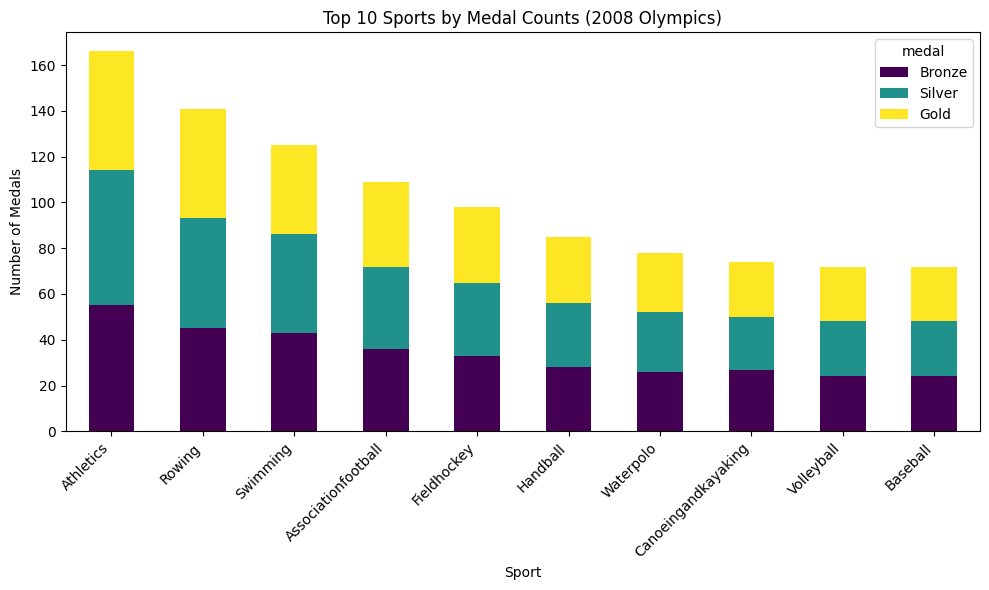

In [121]:
# Add a Total column to sum medals for each sport
pivot_medals_sport['Total'] = pivot_medals_sport.sum(axis=1)

# Sort sports by total medals descending
top_sports = pivot_medals_sport.sort_values('Total', ascending=False).head(10)

# Plot stacked bar chart: Bronze, Silver, Gold
top_sports[['Bronze', 'Silver', 'Gold']].plot(
    kind='bar', stacked=True, figsize=(10,6), colormap='viridis'
)
plt.ylabel("Number of Medals")
plt.xlabel("Sport")
plt.title("Top 10 Sports by Medal Counts (2008 Olympics)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

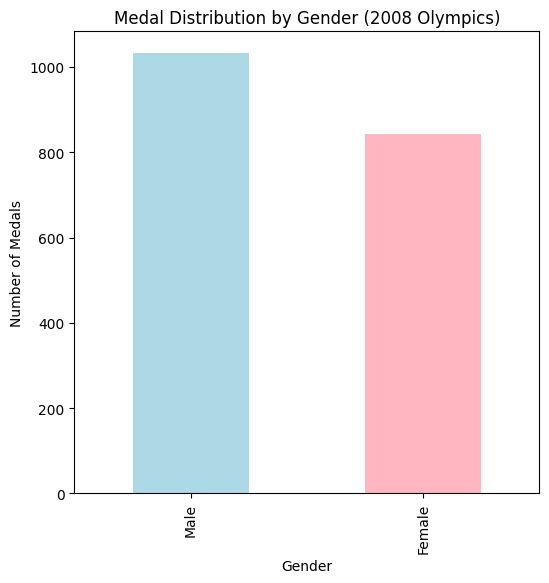

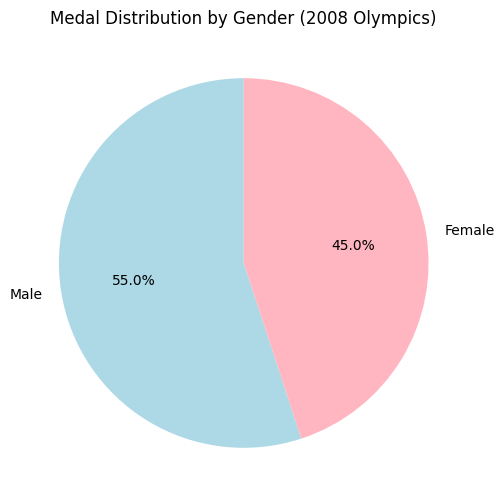

In [122]:
# Count medals by gender
gender_counts = df_olympics_tidy['gender'].value_counts()

# Bar chart
gender_counts.plot(
    kind='bar',
    color=['lightblue', 'lightpink'],
    figsize=(6,6)
)
plt.title("Medal Distribution by Gender (2008 Olympics)")
plt.ylabel("Number of Medals")
plt.xlabel("Gender")
plt.show()

# Pie chart
gender_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightblue', 'lightpink'],
    figsize=(6,6)
)
plt.title("Medal Distribution by Gender (2008 Olympics)")
plt.ylabel("")  # Remove default y-label
plt.show()

## Exploratory Data Analysis (EDA) Visuals

After tidying and cleaning the 2008 Olympic medalist dataset, we can explore patterns and insights in the data.  

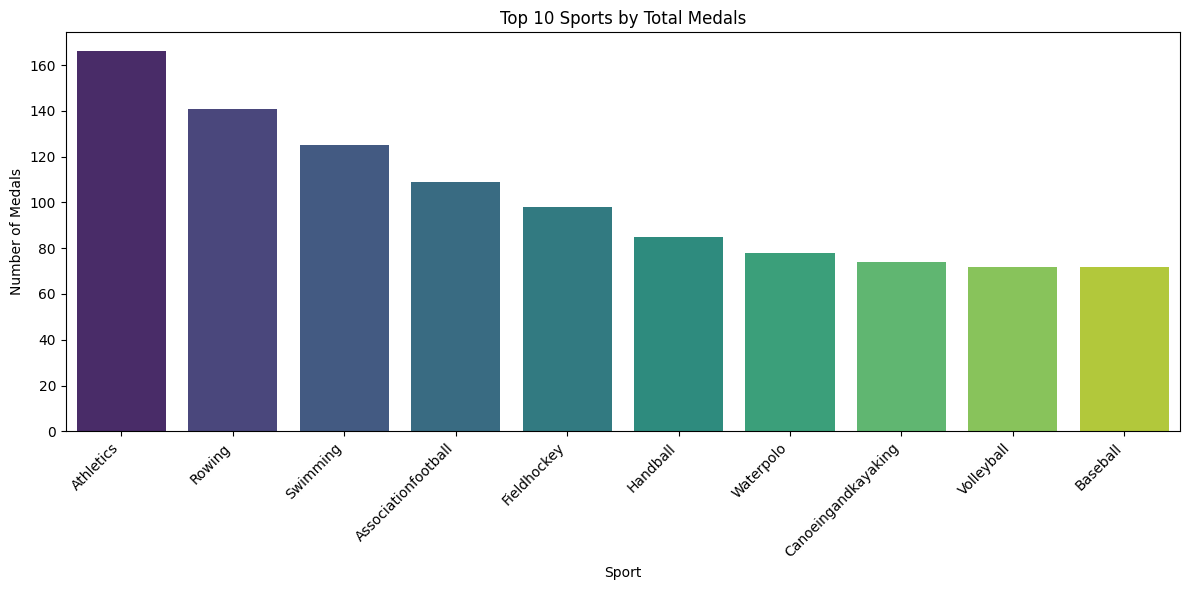

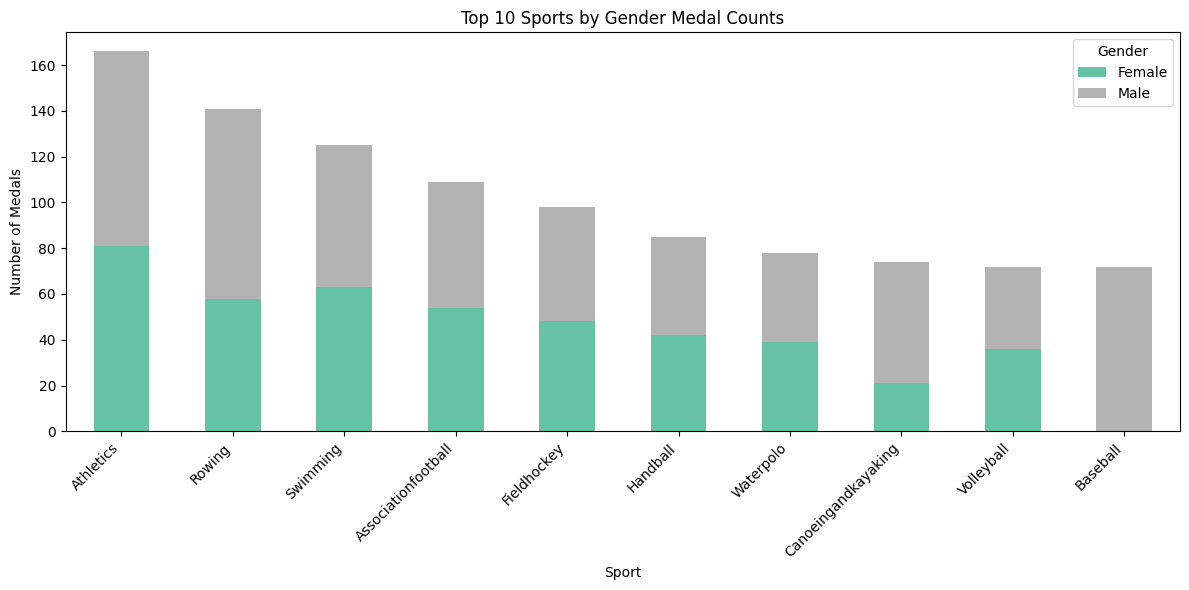

In [123]:
# Total medals per sport
medals_per_sport = df_olympics_tidy.groupby('sport')['medal'].count().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    x=medals_per_sport.index[:10],
    y=medals_per_sport.values[:10],
    hue=medals_per_sport.index[:10],
    palette="viridis",
    legend=False
)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Sports by Total Medals")
plt.ylabel("Number of Medals")
plt.xlabel("Sport")
plt.tight_layout()
plt.show()



# Pivot table by sport and gender
gender_sport_pivot = pd.pivot_table(
    df_olympics_tidy,
    values='medalist_name',
    index='sport',
    columns='gender',
    aggfunc='count',
    fill_value=0
)

# Plot stacked bar chart for top 10 sports by total medals
top10_sports = gender_sport_pivot.sum(axis=1).sort_values(ascending=False).head(10).index
gender_sport_pivot.loc[top10_sports].plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.ylabel("Number of Medals")
plt.xlabel("Sport")
plt.title("Top 10 Sports by Gender Medal Counts")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA) – 2008 Olympic Medalists

This exploratory data analysis focuses on the visual representation of the 2008 Olympics medal data, examining the overall distribution by gender, sport-specific volume, and the internal composition of medals by type and gender.



### 1️⃣ Global Medal Distribution by Gender

The visual data indicates a disparity in the total number of medals awarded to male versus female athletes.

- **Proportional Breakdown:** A pie chart of the total medal distribution shows that **55.0% of all medals were won by men**, while **45.0% were won by women**.  
- **Absolute Volume:** The corresponding bar chart illustrates this gap in absolute numbers, with **male medalists exceeding 1,000** and **female medalists totaling 843**.



### 2️⃣ Top 10 Sports by Medal Volume

The total medal count is concentrated within ten primary sports, with significant variance between the highest and lowest-ranked disciplines in this group.

- **Leading Sports:** Athletics is the most medal-heavy sport, recording **166 total medals**. Rowing follows with **141 medals**, and Swimming ranks third with **125 medals**.  
- **Mid-Tier Rankings:** Association Football (**109 medals**) and Field Hockey (**98 medals**) round out the top five.  
- **Lower Top 10:** The remaining sports (Handball (**85**), Water Polo (**78**), Canoeing and Kayaking (**74**), Volleyball (**72**), and Baseball (**72**)) show a smaller and more consistent medal volume compared to the top three.



### 3️⃣ Medal Composition (Gold, Silver, Bronze)

A stacked bar chart provides a detailed look at the podium distribution within the top ten sports, showing that most disciplines maintain a balanced award structure.

- **High-Volume Sports:**  
  - Athletics: 55 Bronze, 59 Silver, 52 Gold  
  - Rowing: 45 Bronze, 48 Silver, 48 Gold  
  - Swimming: 43 Bronze, 43 Silver, 39 Gold  
- **Even Distribution:** Both Volleyball and Baseball show a perfectly even distribution across the tiers, each awarding **24 Gold, 24 Silver, and 24 Bronze medals**.



### 4️⃣ Gender Representation within Sports

The gender breakdown across the top ten sports highlights different levels of parity and exclusivity.

- **Gender Parity:** Water Polo (39 Female / 39 Male) and Volleyball (36 Female / 36 Male) show **exact equality** in medal counts between genders. Athletics (81 Female / 85 Male), Association Football (54 Female / 55 Male), Field Hockey (48 Female / 50 Male), and Handball (42 Female / 43 Male) all demonstrate **near-parity** with a difference of four medals or fewer.  
- **Female Lead:** Swimming is the only sport in the top ten where women won more medals than men, with **63 medals for female athletes** and **62 for male athletes**.  
- **Significant Disparities:** Canoeing and Kayaking is heavily skewed toward male athletes, who won **53 medals compared to 21 for women**. Rowing also shows a notable gap, with **83 male medalists** and **58 female medalists**.  
- **Total Exclusivity:** Baseball stands out as the only sport in the top ten with **zero female medalists**, as all 72 medals in this category were won by men.



**Summary:**  
The EDA demonstrates clear patterns in medal distribution across gender, sport, and medal type. While several sports show gender parity, others reveal significant disparities, highlighting both historical trends and the competitive landscape of the 2008 Olympics.

## Why the Tidy Data Approach is Important

Adopting the tidy data approach is essential for effective data science because most of the work in analysis is spent cleaning and preparing data — in fact, it is estimated that "80% of data analysis is spent on the process of cleaning and preparing the data" (Hadley Wickham, 2014).  

By ensuring that **each variable has its own column, each observation is a row, and each type of observational unit forms a table**, tidy data provides a standardized framework that links the **physical layout of a dataset to its meaning**.  

The advantages of this approach are evident in several ways:

- **Efficiency in Preparation:** A standard structure means that analysts "don’t need to start from scratch and reinvent the wheel every time" they begin a new project. This allows the focus to remain on domain insights rather than on repetitive logistics.  
- **Ease of Analysis:** Tidy datasets are "easy to manipulate, model, and visualize," which streamlines the analytical workflow. Without a consistent structure, different strategies are required to extract variables, slowing the process and increasing the chance for errors.  
- **Power of Tidy Tools:** Tidy datasets and tidy tools "work hand in hand," meaning functions can be composed together easily. Consistency in structure reduces complexity, as each tool doesn’t need to handle multiple dataset layouts.  
- **Optimized for Programming:** Tidy data is "particularly well suited for vectorized programming languages," because variables from the same observation are always paired, making aggregation, modeling, and visualization simpler.  
- **Consistency Across Tasks:** Fundamental data manipulation verbs — filter, transform, aggregate, and sort — are easier when variables are consistently structured in columns.  

In this notebook, applying the tidy data framework to the **2008 Olympic medalist dataset** allowed us to clean, reshape, and visualize the data efficiently. Without tidying, the original dataset with combined Gender-Sport columns and many null values would have required repetitive, error-prone transformations before any analysis or visualization could occur.